Importing plotly failed. Interactive plots will not work.
16:18:12 - cmdstanpy - INFO - Chain [1] start processing
16:18:12 - cmdstanpy - INFO - Chain [1] done processing



=== En iyi Y-Model Parametreleri (ROCV) ===
RF : {'n_estimators': 400, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1} | ROCV_MAE=71.55
XGB: {'n_estimators': 800, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0} | ROCV_MAE=59.43


/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like


=== Kıyas Tablosu — Full (2025-01..07) ve Short3 (2025-01..03) ===
Horizon        Exog Y-Model   MAE   RMSE  MAPE  w_RF  w_XGB
   Full    Ensemble      RF 58.17  73.79 54.56   NaN    NaN
   Full    Ensemble     XGB 83.24 109.91 77.25   NaN    NaN
   Full  ML-Exog RF      RF 58.30  65.74 50.00   NaN    NaN
   Full  ML-Exog RF     XGB 55.79  66.77 49.66   NaN    NaN
   Full ML-Exog XGB      RF 56.85  65.29 49.07   NaN    NaN
   Full ML-Exog XGB     XGB 55.80  66.62 49.62   NaN    NaN
   Full       Y-Ens  RF+XGB 69.11  88.97 64.82  0.48   0.52
 Short3    Ensemble      RF 46.77  56.07 39.82   NaN    NaN
 Short3    Ensemble     XGB 51.06  60.56 44.15   NaN    NaN
 Short3  ML-Exog RF      RF 45.99  53.56 38.57   NaN    NaN
 Short3  ML-Exog RF     XGB 47.65  65.49 43.11   NaN    NaN
 Short3 ML-Exog XGB      RF 46.12  54.51 38.98   NaN    NaN
 Short3 ML-Exog XGB     XGB 48.26  64.82 43.31   NaN    NaN
 Short3       Y-Ens  RF+XGB 49.44  58.61 42.51  0.48   0.52


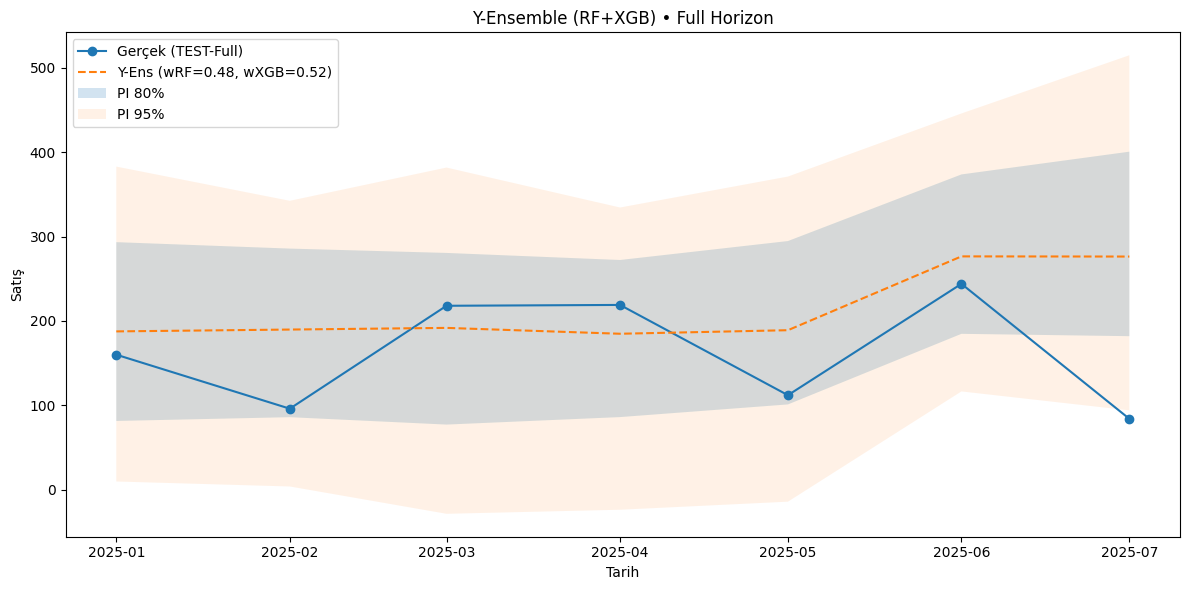

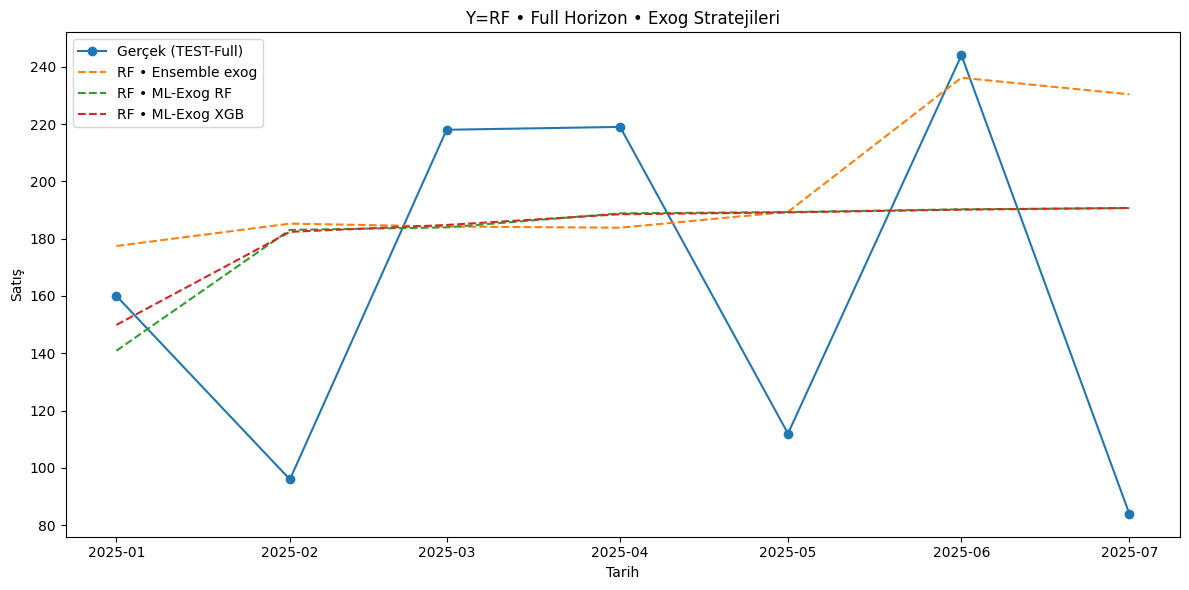

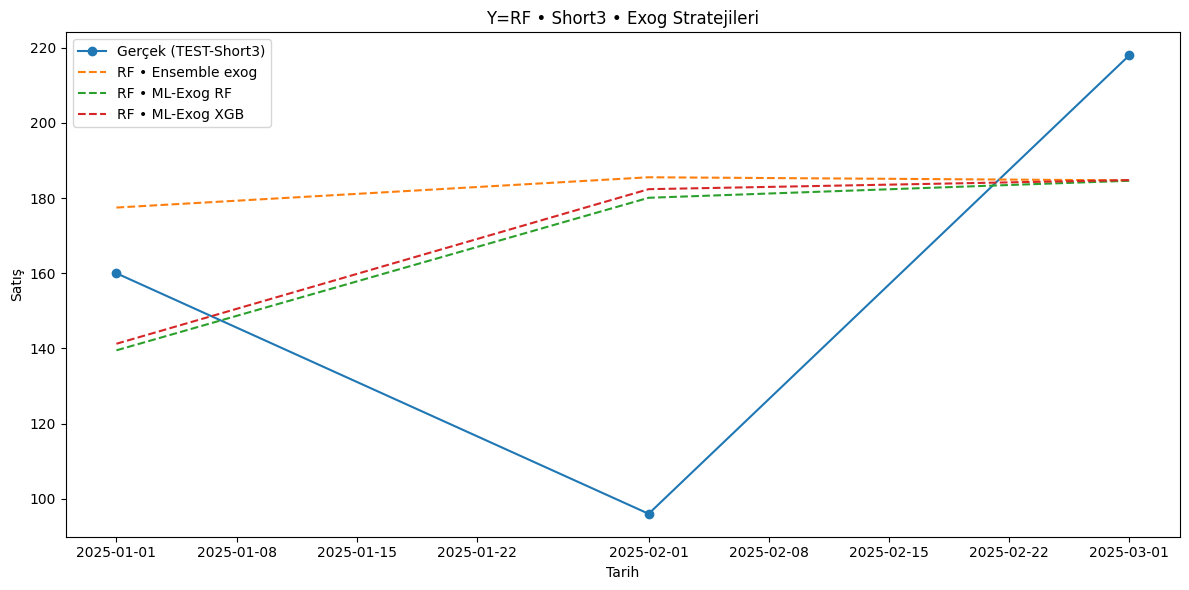

In [1]:
# ==============================================================
# Sales Forecast v2 (Patched & Integrated)
# - Y-Model ROCV HP search (RF, XGB)
# - Exog: (1) Inverse-MAE ensemble (Prophet+SARIMA+ETS, patched)
#         (2) ML-Exog RF (recursive)
#         (3) ML-Exog XGB (recursive)
# - Y-Ensemble (RF+XGB inverse-MAE) + Prediction Intervals (PI)
# - Evaluation: Full TEST (2025-01..07) & Short3 (2025-01..03)
# - Exports: outputs/model_compare.csv, preds_*.csv, plot_full_yens.png
# ==============================================================

import warnings,logging
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------------ Config ------------------
CSV_PATH   = "veri_matrisi_final_sales_orders_stock_calendar_lags_fx.csv"

VAL_START  = pd.Timestamp("2024-07-01")
VAL_END    = pd.Timestamp("2024-12-01")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END   = pd.Timestamp("2025-07-01")
TEST_END_SHORT = pd.Timestamp("2025-03-01")  # 3 aylık kısa ufuk

RANDOM_STATE = 42
EXOG_VAL_H   = 6
EPS_PROPHET  = 0.05  # inverse-MAE'de Prophet'e küçük bias

FEATURES_Y = [
    "orders","stock",
    "orders_lag1","orders_lag3",
    "stock_lag1","stock_lag3",
    "y_lag1",
    "orders_ratio",
    "month","year",
]

# ------------------ Utils ------------------
def mae_rmse_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(((y_pred - y_true)**2).mean())
    denom = np.where(y_true == 0, 1, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape

def ensure_ms_freq(df):
    d = df.copy().sort_values("ds")
    d["ds"] = d["ds"].dt.to_period("M").dt.to_timestamp(how="start")
    d = d.set_index("ds").sort_index()
    d.index = pd.DatetimeIndex(d.index, freq="MS")
    return d.reset_index()

def add_calendar(df):
    d = df.copy()
    d["year"]  = d["ds"].dt.year
    d["month"] = d["ds"].dt.month
    return d

def rolling_impute(s, causal=False):
    x = pd.to_numeric(s, errors="coerce")
    if causal:
        x = x.ffill()
        x = x.rolling(window=3, min_periods=1).mean()
        x = x.bfill()
    else:
        roll = x.rolling(window=3, center=True, min_periods=1).mean()
        x = x.where(~x.isna(), roll).ffill().bfill()
    return x

def smooth_causal_ma(s, window=3):
    x = pd.to_numeric(s, errors="coerce").ffill()
    return x.rolling(window=window, min_periods=1).mean().bfill()

def winsorize_series(s, lower_q=0.05, upper_q=0.95):
    x = pd.to_numeric(s, errors="coerce")
    lo = np.nanpercentile(x, lower_q*100)
    hi = np.nanpercentile(x, upper_q*100)
    return x.clip(lo, hi)

def nonneg(s):
    return pd.to_numeric(s, errors="coerce").clip(lower=0.0)

def build_lags_y(df):
    d = df.copy()
    if "orders" in d.columns and "stock" in d.columns:
        d["orders_ratio"] = d["orders"] / d["stock"].replace(0, np.nan)
    if "y" in d.columns:
        d["y_lag1"] = d["y"].shift(1)
    if "orders" in d.columns:
        d["orders_lag1"] = d["orders"].shift(1)
        d["orders_lag3"] = d["orders"].shift(3)
    if "stock" in d.columns:
        d["stock_lag1"] = d["stock"].shift(1)
        d["stock_lag3"] = d["stock"].shift(3)
    return d

def prep_features_y(df_in, causal=False):
    d = add_calendar(df_in)
    d = build_lags_y(d)
    for col in ["orders","stock"]:
        if col in d.columns:
            d[col] = rolling_impute(d[col], causal=causal)
    for col in ["orders_lag1","orders_lag3","stock_lag1","stock_lag3","y_lag1","orders_ratio"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce").ffill().bfill().fillna(0.0)
    for c in FEATURES_Y:
        if c not in d.columns:
            d[c] = 0.0
    return d.replace([np.inf, -np.inf], np.nan).fillna(0)

# ------------------ Univariate exog (Prophet/SARIMA/ETS) ------------------
def fit_prophet(train_df, value_col):
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
    m.fit(train_df.rename(columns={value_col:"y"}))
    return m

def forecast_prophet(model, steps):
    fut = model.make_future_dataframe(periods=steps, freq="MS")
    fc  = model.predict(fut)[["ds","yhat"]].tail(steps)
    return fc.rename(columns={"yhat":"yhat"})

def sarima_fit_best(y, p_range=(0,3), q_range=(0,3), P_range=(0,1), Q_range=(0,1)):
    best, best_aic = None, np.inf
    for p in range(p_range[0], p_range[1]+1):
        for q in range(q_range[0], q_range[1]+1):
            for P in range(P_range[0], P_range[1]+1):
                for Q in range(Q_range[0], Q_range[1]+1):
                    try:
                        r = SARIMAX(y, order=(p,1,q), seasonal_order=(P,1,Q,12),
                                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                        if r.aic < best_aic:
                            best_aic = r.aic
                            best = ((p,1,q),(P,1,Q,12))
                    except Exception:
                        pass
    return best

def fit_sarima(train_df, value_col):
    y = train_df.set_index("ds")[value_col]
    y.index.freq = "MS"
    best = sarima_fit_best(y)
    if best is None:
        return None
    return SARIMAX(y, order=best[0], seasonal_order=best[1],
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

def forecast_sarima(model, steps, future_idx):
    pred = model.get_forecast(steps=steps).predicted_mean
    return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), "yhat": pred.values})

def fit_ets(train_df, value_col):
    y = train_df.set_index("ds")[value_col]
    y.index.freq = "MS"
    best_model = None
    best_aic = np.inf
    for trend in ["add", "mul", None]:
        for seasonal in ["add", "mul", None]:
            try:
                for damped in [True, False]:
                    if seasonal is None:
                        model = ExponentialSmoothing(y, trend=trend, seasonal=None, damped_trend=damped).fit(optimized=True)
                    else:
                        model = ExponentialSmoothing(y, trend=trend, seasonal=seasonal, seasonal_periods=12,
                                                     damped_trend=damped).fit(optimized=True)
                    aic = getattr(model, "aic", np.inf)
                    if aic < best_aic:
                        best_aic, best_model = aic, model
            except Exception:
                continue
    if best_model is None:
        best_model = ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=12).fit(optimized=True)
    return best_model

def forecast_ets(model, steps, future_idx):
    pred = model.forecast(steps)
    return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), "yhat": pred.values})

def backtest_mae(series_df, value_col, method, val_h=EXOG_VAL_H):
    s_full = series_df[["ds", value_col]].dropna().sort_values("ds")
    s = s_full[s_full["ds"] < TEST_START]
    if len(s) < val_h + 6:
        return np.inf
    cut = s["ds"].max() - pd.DateOffset(months=val_h-1)
    train = s[s["ds"] < cut]
    val   = s[s["ds"] >= cut]
    steps = len(val)
    try:
        if method == "prophet":
            m = fit_prophet(train, value_col)
            yhat = forecast_prophet(m, steps)["yhat"].values
        elif method == "sarima":
            m = fit_sarima(train, value_col)
            if m is None:
                return np.inf
            yhat = forecast_sarima(m, steps, val["ds"].values)["yhat"].values
        else:
            m = fit_ets(train, value_col)
            yhat = forecast_ets(m, steps, val["ds"].values)["yhat"].values
    except Exception:
        return np.inf
    return mae_rmse_mape(val[value_col].values, yhat)[0]

# Patched inverse-MAE ensemble (orders & stock ayrı ayrı) + postprocess
def _postprocess_exog(df):
    d = df.copy()
    for c in ["orders","stock"]:
        if c in d.columns:
            d[c] = smooth_causal_ma(d[c], window=3)
            d[c] = winsorize_series(d[c], 0.05, 0.95)
            d[c] = nonneg(d[c])
    return d

def build_exog_inverse_mae_PATCH(df_all, future_idx, val_h=EXOG_VAL_H, eps_prophet=EPS_PROPHET):
    out = pd.DataFrame({"ds": future_idx})
    for col in ["orders","stock"]:
        s = df_all[["ds", col]].dropna().sort_values("ds")
        s = s[s["ds"] < TEST_START]
        if s.empty:
            out[col] = 0.0; continue
        steps = len(future_idx)
        mae_p = backtest_mae(s, col, "prophet", val_h)
        mae_s = backtest_mae(s, col, "sarima",  val_h)
        mae_e = backtest_mae(s, col, "ets",     val_h)

        # Forecasts
        try:
            mp  = fit_prophet(s, col); fcp = forecast_prophet(mp, steps).rename(columns={"yhat":"p"})
        except Exception: fcp = pd.DataFrame({"ds": future_idx, "p": np.nan})
        try:
            ms  = fit_sarima(s, col);  fcs = forecast_sarima(ms, steps, future_idx).rename(columns={"yhat":"s"})
        except Exception: fcs = pd.DataFrame({"ds": future_idx, "s": np.nan})
        try:
            me  = fit_ets(s, col);     fce = forecast_ets(me, steps, future_idx).rename(columns={"yhat":"e"})
        except Exception: fce = pd.DataFrame({"ds": future_idx, "e": np.nan})

        maes = np.array([mae_p, mae_s, mae_e], dtype=float)
        maes = np.where(~np.isfinite(maes) | (maes <= 0), np.nan, maes)
        inv  = 1.0 / np.where(np.isnan(maes), np.inf, maes)
        if np.isfinite(inv).sum() == 0:
            wp, ws, we = 0.60, 0.25, 0.15
        else:
            w = inv / inv.sum()
            w[0] += eps_prophet
            w = w / w.sum()
            wp, ws, we = w[0], w[1], w[2]

        tmp = (pd.DataFrame({"ds": future_idx})
                 .merge(fcp, on="ds", how="left")
                 .merge(fcs, on="ds", how="left")
                 .merge(fce, on="ds", how="left"))
        tmp[col] = (wp*tmp["p"] + ws*tmp["s"] + we*tmp["e"])
        out = out.merge(tmp[["ds",col]], on="ds", how="left")
    return _postprocess_exog(out)

# ------------------ Y-learners (old grid kept for reference; new ROCV below) ------------------
def optimize_rf(train_df, val_df):
    grid = {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 8, 12],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
    }
    best, best_mae = None, np.inf
    for n in grid["n_estimators"]:
        for md in grid["max_depth"]:
            for mss in grid["min_samples_split"]:
                for msl in grid["min_samples_leaf"]:
                    params = dict(n_estimators=n, max_depth=md, min_samples_split=mss,
                                  min_samples_leaf=msl, random_state=RANDOM_STATE, n_jobs=-1)
                    mdl = RandomForestRegressor(**params).fit(train_df[FEATURES_Y], train_df["y"])
                    pred = mdl.predict(val_df[FEATURES_Y])
                    mae = mae_rmse_mape(val_df["y"], pred)[0]
                    if mae < best_mae:
                        best_mae, best = mae, (params, mdl)
    return best[1], best[0], best_mae

def optimize_xgb(train_df, val_df):
    grid = {
        "n_estimators": [400, 700],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 4],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "reg_lambda": [1.0, 2.0],
    }
    best, best_mae = None, np.inf
    X_tr = train_df[FEATURES_Y].to_numpy(); y_tr = train_df["y"].to_numpy()
    X_va = val_df[FEATURES_Y].to_numpy();   y_va = val_df["y"].to_numpy()
    for n in grid["n_estimators"]:
        for lr in grid["learning_rate"]:
            for md in grid["max_depth"]:
                for ss in grid["subsample"]:
                    for cs in grid["colsample_bytree"]:
                        for rl in grid["reg_lambda"]:
                            params = dict(
                                n_estimators=n, learning_rate=lr, max_depth=md,
                                subsample=ss, colsample_bytree=cs, reg_lambda=rl,
                                random_state=RANDOM_STATE
                            )
                            mdl = XGBRegressor(**params)
                            mdl.fit(X_tr, y_tr, verbose=False)
                            pred = mdl.predict(X_va)
                            mae = mae_rmse_mape(y_va, pred)[0]
                            if mae < best_mae:
                                best_mae, best = mae, (params, mdl)
    return best[1], best[0], best_mae

# ------------------ ROCV (v2) ------------------
def rolling_origin_splits(df, n_splits=3, min_train_months=24):
    d = df.sort_values("ds").copy()
    if d["ds"].nunique() < (min_train_months + n_splits):
        yield (d[d["ds"] < d["ds"].max() - pd.DateOffset(months=3)],
               d[d["ds"] >= d["ds"].max() - pd.DateOffset(months=3)])
        return
    for k in range(n_splits, 0, -1):
        val_end = d["ds"].max() - pd.DateOffset(months=k-1)
        val_start = val_end - pd.DateOffset(months=2)  # 3 aylık val
        train_end = val_start - pd.DateOffset(days=1)
        train = d[(d["ds"] <= train_end)]
        val   = d[(d["ds"] >= val_start) & (d["ds"] <= val_end)]
        if len(train) >= min_train_months and len(val) >= 2:
            yield train, val

def optimize_rf_rocv(df_trainval, base_grid=None):
    if base_grid is None:
        base_grid = {
            "n_estimators": [400, 700],
            "max_depth": [None, 8, 12],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
        }
    best, best_score = None, np.inf
    for params in (dict(zip(base_grid.keys(), v)) for v in product(*base_grid.values())):
        maes = []
        for tr, va in rolling_origin_splits(df_trainval, n_splits=3, min_train_months=24):
            mdl = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
            mdl.fit(tr[FEATURES_Y], tr["y"])
            pred = mdl.predict(va[FEATURES_Y])
            maes.append(mean_absolute_error(va["y"], pred))
        score = np.mean(maes) if maes else np.inf
        if score < best_score:
            best_score, best = score, params
    final = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best).fit(df_trainval[FEATURES_Y], df_trainval["y"])
    return final, best, best_score

def optimize_xgb_rocv(df_trainval, base_grid=None):
    if base_grid is None:
        base_grid = {
            "n_estimators": [500, 800],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 4],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "reg_lambda": [1.0, 2.0],
        }
    best, best_score = None, np.inf
    for params in (dict(zip(base_grid.keys(), v)) for v in product(*base_grid.values())):
        maes = []
        for tr, va in rolling_origin_splits(df_trainval, n_splits=3, min_train_months=24):
            mdl = XGBRegressor(random_state=RANDOM_STATE, **params)
            mdl.fit(tr[FEATURES_Y].to_numpy(), tr["y"].to_numpy(), verbose=False)
            pred = mdl.predict(va[FEATURES_Y].to_numpy())
            maes.append(mean_absolute_error(va["y"], pred))
        score = np.mean(maes) if maes else np.inf
        if score < best_score:
            best_score, best = score, params
    final = XGBRegressor(random_state=RANDOM_STATE, **best)
    final.fit(df_trainval[FEATURES_Y].to_numpy(), df_trainval["y"].to_numpy(), verbose=False)
    return final, best, best_score

# ------------------ Y recursive forward ------------------
def recursive_forward_predict_y(model, x_cols, hist_df, future_exog, start_ds, end_ds):
    future_idx = pd.date_range(start_ds, end_ds, freq="MS")
    future_part = pd.DataFrame({"ds": future_idx}).merge(future_exog, on="ds", how="left")
    full = pd.concat([hist_df, future_part], ignore_index=True).sort_values("ds")

    preds = []
    for ds in future_idx:
        tmp = prep_features_y(full.copy(), causal=True)
        row = tmp.loc[tmp["ds"] == ds].copy()
        X = row[x_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
        y_hat = model.predict(X)[0]
        preds.append({"ds": ds, "yhat": y_hat})
        full.loc[full["ds"] == ds, "y"] = y_hat
        for c in ["orders","stock"]:
            if c in full.columns:
                full[c] = rolling_impute(full[c], causal=True)
    preds_df = pd.DataFrame(preds)
    used_future = full.loc[full["ds"].isin(future_idx)].copy()
    return preds_df, used_future

# ------------------ ML-Exog (orders/stock) modülleri ------------------
EXOG_FEATURES = ["lag1","lag3","month","year"]  # exog modeller için sade set

def make_exog_feature_frame(df_var, var_col):
    d = df_var[["ds", var_col]].sort_values("ds").copy()
    d["lag1"] = d[var_col].shift(1)
    d["lag3"] = d[var_col].shift(3)
    d["month"] = d["ds"].dt.month
    d["year"]  = d["ds"].dt.year
    return d

def train_exog_rf(df_var, var_col, cutoff):
    d = make_exog_feature_frame(df_var[df_var["ds"] < cutoff], var_col).dropna()
    X = d[EXOG_FEATURES]; y = d[var_col]
    rf = RandomForestRegressor(
        n_estimators=400, max_depth=8, min_samples_split=2, min_samples_leaf=1,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    rf.fit(X, y)
    return rf

def train_exog_xgb(df_var, var_col, cutoff):
    d = make_exog_feature_frame(df_var[df_var["ds"] < cutoff], var_col).dropna()
    X = d[EXOG_FEATURES].to_numpy(); y = d[var_col].to_numpy()
    xgb = XGBRegressor(
        n_estimators=500, learning_rate=0.08, max_depth=3,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.2,
        random_state=RANDOM_STATE
    )
    xgb.fit(X, y, verbose=False)
    return xgb

def recursive_forecast_exog(model, hist_df, var_col, start_ds, end_ds):
    future_idx = pd.date_range(start_ds, end_ds, freq="MS")
    full = hist_df[["ds", var_col]].sort_values("ds").copy()
    out = []
    for ds in future_idx:
        tmp = make_exog_feature_frame(full, var_col)
        row = tmp[tmp["ds"] == ds][EXOG_FEATURES]
        if row.empty:
            row = pd.DataFrame({
                "lag1": [full[var_col].iloc[-1] if len(full) else 0.0],
                "lag3": [full[var_col].iloc[-3] if len(full) >= 3 else (full[var_col].iloc[-1] if len(full) else 0.0)],
                "month":[ds.month], "year":[ds.year]
            })
        x = row.to_numpy()
        yhat = model.predict(x)[0]
        out.append({"ds": ds, var_col: float(max(0.0, yhat))})
        full = pd.concat([full, pd.DataFrame({"ds":[ds], var_col:[yhat]})], ignore_index=True)
    return pd.DataFrame(out)

def build_exog_ml(df_all, future_idx, learner="rf"):
    out = pd.DataFrame({"ds": future_idx})
    for col in ["orders","stock"]:
        s = df_all[["ds", col]].dropna().sort_values("ds").copy()
        s = s[s["ds"] < TEST_START]
        if s.empty:
            out[col] = 0.0; continue
        if learner == "rf":
            mdl = train_exog_rf(df_all[["ds", col]].copy(), col, cutoff=TEST_START)
        else:
            mdl = train_exog_xgb(df_all[["ds", col]].copy(), col, cutoff=TEST_START)
        fc = recursive_forecast_exog(mdl, df_all[df_all["ds"] < TEST_START][["ds", col]].copy(), col,
                                     start_ds=future_idx.min(), end_ds=future_idx.max())
        out = out.merge(fc, on="ds", how="left")
    return _postprocess_exog(out)

# ------------------ Load & prepare Y-data ------------------
df_raw = pd.read_csv(CSV_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
for c in ["y","orders","stock"]:
    if c in df_raw.columns: df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")
df_raw = ensure_ms_freq(df_raw)

mask_train = (df_raw["ds"] < VAL_START)
mask_val   = (df_raw["ds"] >= VAL_START) & (df_raw["ds"] <= VAL_END)
mask_test  = (df_raw["ds"] >= TEST_START) & (df_raw["ds"] <= TEST_END)
mask_test_short = (df_raw["ds"] >= TEST_START) & (df_raw["ds"] <= TEST_END_SHORT)

train_df = prep_features_y(df_raw.loc[mask_train].copy(), causal=False)
val_df   = prep_features_y(df_raw.loc[mask_val].copy(),   causal=True)
test_df  = prep_features_y(df_raw.loc[mask_test].copy(),  causal=True)
test_df_short = prep_features_y(df_raw.loc[mask_test_short].copy(), causal=True)

# ------------------ ROCV HP search on (train+val) ------------------
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

rf_model,  rf_params,  rf_rocv_mae  = optimize_rf_rocv(trainval_df)
xgb_model, xgb_params, xgb_rocv_mae = optimize_xgb_rocv(trainval_df)

print("\n=== En iyi Y-Model Parametreleri (ROCV) ===")
print("RF :", rf_params,  f"| ROCV_MAE={rf_rocv_mae:.2f}")
print("XGB:", xgb_params, f"| ROCV_MAE={xgb_rocv_mae:.2f}")

# ------------------ Exog tablolarını üret ------------------
future_idx_full  = pd.date_range(TEST_START, TEST_END, freq="MS")
future_idx_short = pd.date_range(TEST_START, TEST_END_SHORT, freq="MS")

# 1) Ensemble (Inverse-MAE Patched)
exog_ens_full  = build_exog_inverse_mae_PATCH(df_raw[["ds","orders","stock"]], future_idx_full,  EXOG_VAL_H, EPS_PROPHET)
exog_ens_short = build_exog_inverse_mae_PATCH(df_raw[["ds","orders","stock"]], future_idx_short, EXOG_VAL_H, EPS_PROPHET)

# 2) ML-Exog RF
exog_rf_full   = build_exog_ml(df_raw[["ds","orders","stock"]], future_idx_full,  learner="rf")
exog_rf_short  = build_exog_ml(df_raw[["ds","orders","stock"]], future_idx_short, learner="rf")

# 3) ML-Exog XGB
exog_xgb_full  = build_exog_ml(df_raw[["ds","orders","stock"]], future_idx_full,  learner="xgb")
exog_xgb_short = build_exog_ml(df_raw[["ds","orders","stock"]], future_idx_short, learner="xgb")

# recursive geçmiş (TRAIN+VAL gerçekleri)
hist_min = pd.concat([train_df, val_df], ignore_index=True)[["ds","y","orders","stock","month","year"]].copy()

# ------------------ Değerlendir: RF & XGB tekil ------------------
def eval_block(tag, future_idx, exog_table):
    rows = []
    # RF
    pred_rf, _  = recursive_forward_predict_y(rf_model,  FEATURES_Y, hist_min.copy(), exog_table, TEST_START, future_idx.max())
    eval_rf     = prep_features_y(df_raw[df_raw["ds"].isin(future_idx)][["ds","y","orders","stock"]], causal=True)[["ds","y"]].merge(pred_rf, on="ds", how="left")
    m1, r1, p1  = mae_rmse_mape(eval_rf["y"], eval_rf["yhat"])
    rows.append({"Horizon": tag, "Exog": "This", "Y-Model": "RF",  "MAE": m1, "RMSE": r1, "MAPE": p1})
    # XGB
    pred_xgb, _ = recursive_forward_predict_y(xgb_model, FEATURES_Y, hist_min.copy(), exog_table, TEST_START, future_idx.max())
    eval_xgb    = prep_features_y(df_raw[df_raw["ds"].isin(future_idx)][["ds","y","orders","stock"]], causal=True)[["ds","y"]].merge(pred_xgb, on="ds", how="left")
    m2, r2, p2  = mae_rmse_mape(eval_xgb["y"], eval_xgb["yhat"])
    rows.append({"Horizon": tag, "Exog": "This", "Y-Model": "XGB", "MAE": m2, "RMSE": r2, "MAPE": p2})
    return pd.DataFrame(rows), {"RF":eval_rf, "XGB":eval_xgb}

# Full horizon
res_full_ens,  eval_full_ens  = eval_block("Full",  future_idx_full,  exog_ens_full)
res_full_rf ,  eval_full_rf   = eval_block("Full",  future_idx_full,  exog_rf_full)
res_full_xgb,  eval_full_xgb  = eval_block("Full",  future_idx_full,  exog_xgb_full)

# Short horizon (3 ay)
res_short_ens, eval_short_ens = eval_block("Short3", future_idx_short, exog_ens_short)
res_short_rf , eval_short_rf  = eval_block("Short3", future_idx_short, exog_rf_short)
res_short_xgb, eval_short_xgb = eval_block("Short3", future_idx_short, exog_xgb_short)

def tag_name(df_rows, name):
    d = df_rows.copy()
    d["Exog"] = name
    return d

res_all = pd.concat([
    tag_name(res_full_ens,  "Ensemble"),
    tag_name(res_full_rf,   "ML-Exog RF"),
    tag_name(res_full_xgb,  "ML-Exog XGB"),
    tag_name(res_short_ens, "Ensemble"),
    tag_name(res_short_rf,  "ML-Exog RF"),
    tag_name(res_short_xgb, "ML-Exog XGB"),
], ignore_index=True)

# ------------------ Y-Ensemble (RF+XGB) + PI ------------------
def y_ensemble_inverse_mae(y_true_val, yhat_rf_val, yhat_xgb_val, eps=1e-6):
    mae_rf  = mean_absolute_error(y_true_val, yhat_rf_val)
    mae_xgb = mean_absolute_error(y_true_val, yhat_xgb_val)
    w_rf  = 1.0 / (mae_rf  + eps)
    w_xgb = 1.0 / (mae_xgb + eps)
    w_sum = w_rf + w_xgb
    return w_rf / w_sum, w_xgb / w_sum

def recursive_forward_predict_y_with_pi(models, weights, x_cols, hist_df, future_exog, start_ds, end_ds,
                                        approx_mae, B=300, alpha_low=0.10, alpha_high=0.90):
    future_idx = pd.date_range(start_ds, end_ds, freq="MS")
    future_part = pd.DataFrame({"ds": future_idx}).merge(future_exog, on="ds", how="left")
    full = pd.concat([hist_df, future_part], ignore_index=True).sort_values("ds")

    preds_point = []
    for ds in future_idx:
        tmp = prep_features_y(full.copy(), causal=True)
        row = tmp.loc[tmp["ds"] == ds].copy()
        X = row[x_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()

        y_rf  = models["RF"].predict(X)[0]
        y_xgb = models["XGB"].predict(X)[0]
        y_hat = weights["RF"] * y_rf + weights["XGB"] * y_xgb
        preds_point.append({"ds": ds, "yhat": y_hat})

        full.loc[full["ds"] == ds, "y"] = y_hat
        for c in ["orders","stock"]:
            if c in full.columns:
                full[c] = rolling_impute(full[c], causal=True)

    preds_point = pd.DataFrame(preds_point)

    # Basit bootstrap: Laplace gürültü ~ approx_mae
    scale = float(max(1e-6, approx_mae))
    noise = np.random.laplace(loc=0.0, scale=scale, size=(len(preds_point), B))
    sims = preds_point["yhat"].to_numpy().reshape(-1,1) + noise

    preds_point["pi80_lo"] = np.nanquantile(sims, alpha_low, axis=1)
    preds_point["pi80_hi"] = np.nanquantile(sims, alpha_high, axis=1)
    preds_point["pi95_lo"] = np.nanquantile(sims, 0.025, axis=1)
    preds_point["pi95_hi"] = np.nanquantile(sims, 0.975, axis=1)

    used_future = full.loc[full["ds"].isin(future_idx)].copy()
    return preds_point, used_future

def eval_block_with_y_ensemble(tag, future_idx, exog_table):
    # VAL döneminde ağırlıkları hesapla
    val_hist = prep_features_y(df_raw.loc[(df_raw["ds"] >= VAL_START) & (df_raw["ds"] <= VAL_END)][["ds","y","orders","stock"]], causal=True)
    # VAL için exog: gerçeklerden
    val_exog = df_raw.loc[(df_raw["ds"] >= VAL_START) & (df_raw["ds"] <= VAL_END)][["ds","orders","stock"]].copy()
    # Val preds
    val_pred_rf,  _ = recursive_forward_predict_y(rf_model,  FEATURES_Y, train_df[["ds","y","orders","stock","month","year"]].copy(), val_exog, VAL_START, VAL_END)
    val_pred_xgb, _ = recursive_forward_predict_y(xgb_model, FEATURES_Y, train_df[["ds","y","orders","stock","month","year"]].copy(), val_exog, VAL_START, VAL_END)
    val_join = val_hist[["ds","y"]].merge(val_pred_rf, on="ds", how="left").rename(columns={"yhat":"yhat_rf"}) \
                                   .merge(val_pred_xgb, on="ds", how="left").rename(columns={"yhat":"yhat_xgb"})
    w_rf, w_xgb = y_ensemble_inverse_mae(val_join["y"].values, val_join["yhat_rf"].values, val_join["yhat_xgb"].values)
    weights = {"RF": w_rf, "XGB": w_xgb}

    # TEST için ensemble + PI
    approx_mae = 0.5*(rf_rocv_mae + xgb_rocv_mae)
    preds_ens, _ = recursive_forward_predict_y_with_pi(
        models={"RF": rf_model, "XGB": xgb_model},
        weights=weights,
        x_cols=FEATURES_Y,
        hist_df=hist_min.copy(),
        future_exog=exog_table,
        start_ds=future_idx.min(),
        end_ds=future_idx.max(),
        approx_mae=approx_mae,
        B=300
    )
    # metrik
    eval_df = prep_features_y(df_raw[df_raw["ds"].isin(future_idx)][["ds","y","orders","stock"]], causal=True)[["ds","y"]] \
                .merge(preds_ens, on="ds", how="left")
    m, r, p = mae_rmse_mape(eval_df["y"], eval_df["yhat"])
    row = pd.DataFrame([{"Horizon": tag, "Exog": "Y-Ens", "Y-Model": "RF+XGB", "MAE": m, "RMSE": r, "MAPE": p,
                         "w_RF": w_rf, "w_XGB": w_xgb}])
    return row, eval_df

# Y-ensemble değerlendirme (exog olarak Ensemble'ı kullanıyoruz; istersen diğerleriyle de çağırabilirsin)
res_full_yens,  eval_full_yens  = eval_block_with_y_ensemble("Full",  future_idx_full,  exog_ens_full)
res_short_yens, eval_short_yens = eval_block_with_y_ensemble("Short3", future_idx_short, exog_ens_short)

res_all = pd.concat([res_all, res_full_yens, res_short_yens], ignore_index=True)

# ------------------ Raporlama & Grafikler ------------------
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("\n=== Kıyas Tablosu — Full (2025-01..07) ve Short3 (2025-01..03) ===")
print(res_all.sort_values(["Horizon","Exog","Y-Model","MAE"]).to_string(index=False))

os.makedirs("outputs", exist_ok=True)
os.makedirs("logs", exist_ok=True)

# Kıyas tablosu
res_all.sort_values(["Horizon","Exog","Y-Model"]).to_csv("outputs/model_compare.csv", index=False)

# Tahmin serileri (Y-Ens)
eval_full_yens.to_csv("outputs/preds_full_yens.csv", index=False)
eval_short_yens.to_csv("outputs/preds_short_yens.csv", index=False)

# Grafik: Full horizon, Y-Ens + PI
plt.figure(figsize=(12,6))
plt.plot(eval_full_yens["ds"], eval_full_yens["y"], "o-", label="Gerçek (TEST-Full)")
plt.plot(eval_full_yens["ds"], eval_full_yens["yhat"], "--", label=f"Y-Ens (wRF={res_full_yens['w_RF'].iloc[0]:.2f}, wXGB={res_full_yens['w_XGB'].iloc[0]:.2f})")
plt.fill_between(eval_full_yens["ds"], eval_full_yens["pi80_lo"], eval_full_yens["pi80_hi"], alpha=0.2, label="PI 80%")
plt.fill_between(eval_full_yens["ds"], eval_full_yens["pi95_lo"], eval_full_yens["pi95_hi"], alpha=0.1, label="PI 95%")
plt.title("Y-Ensemble (RF+XGB) • Full Horizon")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.savefig("outputs/plot_full_yens.png", dpi=160)
plt.show()

# ------------------ (Opsiyonel) RF için 3 exog karşılaştırma görselleri ------------------
# Full
plt.figure(figsize=(12,6))
plt.plot(eval_full_ens["RF"]["ds"], eval_full_ens["RF"]["y"], "o-", label="Gerçek (TEST-Full)")
plt.plot(eval_full_ens["RF"]["ds"], eval_full_ens["RF"]["yhat"], "--", label="RF • Ensemble exog")
plt.plot(eval_full_rf["RF"]["ds"],  eval_full_rf["RF"]["yhat"],  "--", label="RF • ML-Exog RF")
plt.plot(eval_full_xgb["RF"]["ds"], eval_full_xgb["RF"]["yhat"], "--", label="RF • ML-Exog XGB")
plt.title("Y=RF • Full Horizon • Exog Stratejileri")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.savefig("outputs/plot_full_rf_vs_exogs.png", dpi=160)
plt.show()

# Short3
plt.figure(figsize=(12,6))
plt.plot(eval_short_ens["RF"]["ds"], eval_short_ens["RF"]["y"], "o-", label="Gerçek (TEST-Short3)")
plt.plot(eval_short_ens["RF"]["ds"], eval_short_ens["RF"]["yhat"], "--", label="RF • Ensemble exog")
plt.plot(eval_short_rf["RF"]["ds"],  eval_short_rf["RF"]["yhat"],  "--", label="RF • ML-Exog RF")
plt.plot(eval_short_xgb["RF"]["ds"], eval_short_xgb["RF"]["yhat"], "--", label="RF • ML-Exog XGB")
plt.title("Y=RF • Short3 • Exog Stratejileri")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.savefig("outputs/plot_short3_rf_vs_exogs.png", dpi=160)
plt.show()
